# Cinética Química: Reações de Primeira e Segunda Ordem
---


### Reação de Primeira Ordem

A lei de velocidade é dada por:

$$
\frac{d[A]}{dt} = -k_1 [A]
$$

Separando variáveis e integrando:

$$
\frac{d[A]}{[A]} = -k_1 dt
$$

$$
\int_{[A]_0}^{[A]} \frac{d[A]}{[A]} = \int_{0}^{t} -k_1 dt
$$

$$
\ln [A] - \ln [A]_0 = -k_1 t
$$

Logo,

$$
\boxed{[A] = [A]_0 e^{-k_1 t}}
$$

- O decaimento é **exponencial**.  
- A meia-vida é **independente** da concentração inicial:

$$
\boxed{t_{1/2} = -\frac{\ln 1/2}{k_1}}
$$


### Reação de Segunda Ordem

Para uma reação $2A \to \text{produtos}$, a lei de velocidade é:

$$
\frac{d[A]}{dt} = -k_2 [A]^2
$$

Separando e integrando:

$$
\frac{d[A]}{[A]^2} = -k_2 dt
$$

$$
\int_{[A]_0}^{[A]} \frac{d[A]}{[A]^2} = \int_{0}^{t} -k_2 dt
$$

$$
-\frac{1}{[A]} + \frac{1}{[A]_0} = -k_2 t
$$

Logo,

$$
\frac{1}{[A]} = \frac{1}{[A]_0} + k_2 t
$$

$$
\boxed{[A] = \frac{[A]_0}{1 + k_2t[A]_0}}
$$

- O decaimento segue uma **lei hiperbólica**.  
- A meia-vida **depende** da concentração inicial:

$$
\boxed{t_{1/2} = \frac{1}{k_2 [A]_0}}
$$


## Comparação entre 1ª e 2ª Ordem

- Na **1ª ordem**, cada molécula tem probabilidade constante de reagir → **decaimento exponencial**.
- Na **2ª ordem**, duas moléculas precisam colidir → velocidade proporcional a $[A]^2$.  
  Quando a concentração diminui, as colisões caem ainda mais rápido → o decaimento é mais lento nas caudas.

**Resumo:**
- **1ª ordem** → meia-vida constante.  
- **2ª ordem** → meia-vida depende de $[A]_0$.  


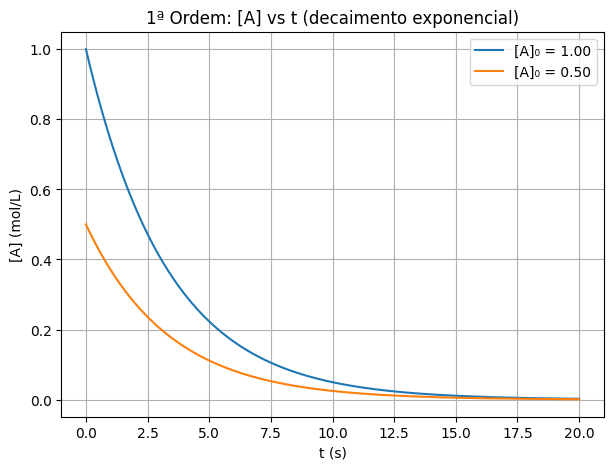

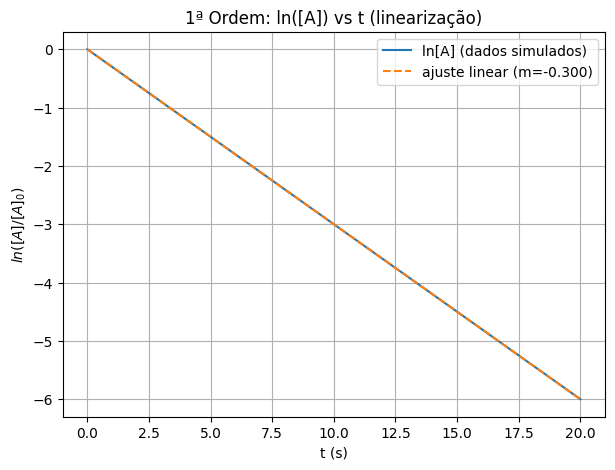

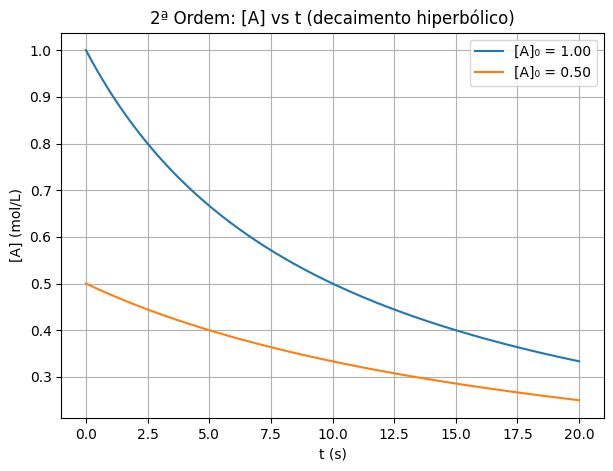

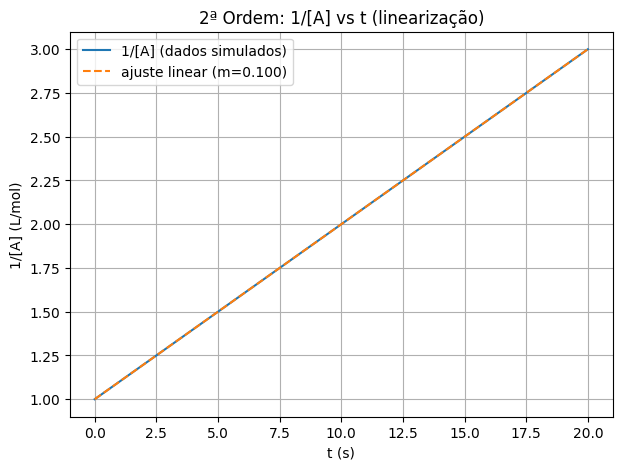

1ª ordem: inclinação obtida = -0.300, esperado = -0.300
2ª ordem: inclinação obtida = 0.100, esperado = 0.100


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PARÂMETROS DO SISTEMA
# ==========================================================
A0 = 1.0          # concentração inicial de A (mol/L, por exemplo)
k1 = 0.3          # constante de velocidade de 1ª ordem (s^-1)
k2 = 0.1          # constante de velocidade de 2ª ordem (L·mol^-1·s^-1)
t_max = 20.0      # tempo máximo de simulação (s)
nt = 500          # número de pontos no vetor de tempo
t = np.linspace(0, t_max, nt)  # vetor de tempo igualmente espaçado

# Simularemos duas condições iniciais: [A]₀ e [A]₀/2
A0_list = [A0, A0/2]

# ==========================================================
# FUNÇÕES ANALÍTICAS (soluções integradas das leis de velocidade)
# ==========================================================
def first_order(A0, k, t):
    """
    Retorna a concentração [A](t) para uma reação de 1ª ordem.
    Equação integrada: [A](t) = [A]₀ * exp(-k * t)
    """
    return A0 * np.exp(-k * t)

def second_order(A0, k, t):
    """
    Retorna a concentração [A](t) para uma reação de 2ª ordem (2A -> produtos).
    Equação integrada: 1/[A](t) = 1/[A]₀ + k * t
    => [A](t) = [A]₀ / (1 + k * [A]₀ * t)
    """
    return A0 / (1 + k * A0 * t)

# ==========================================================
# 1) Gráfico: [A] vs t (1ª ordem) para duas concentrações iniciais
# ==========================================================
plt.figure(figsize=(7,5))
for A0_i in A0_list:
    A = first_order(A0_i, k1, t)
    plt.plot(t, A, label=f"[A]₀ = {A0_i:.2f}")
plt.xlabel("t (s)")
plt.ylabel("[A] (mol/L)")
plt.title("1ª Ordem: [A] vs t (decaimento exponencial)")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# 2) Gráfico: ln([A]) vs t (linearização 1ª ordem) para [A]₀
# ==========================================================
# Na 1ª ordem, ln[A] = -k*t + ln[A]₀ → gráfico linear
plt.figure(figsize=(7,5))
A = first_order(A0, k1, t)
lnA = np.log(A / A0)

# Ajuste linear: retorna inclinação m e intercepto b
m, b = np.polyfit(t, lnA, 1)  

plt.plot(t, lnA, label="ln[A] (dados simulados)")
plt.plot(t, m*t + b, linestyle='--', label=f"ajuste linear (m={m:.3f})")
plt.xlabel("t (s)")
plt.ylabel("$ln([A]/[A]_0)$")
plt.title("1ª Ordem: ln([A]) vs t (linearização)")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# 3) Gráfico: [A] vs t (2ª ordem) para duas concentrações iniciais
# ==========================================================
plt.figure(figsize=(7,5))
for A0_i in A0_list:
    A = second_order(A0_i, k2, t)
    plt.plot(t, A, label=f"[A]₀ = {A0_i:.2f}")
plt.xlabel("t (s)")
plt.ylabel("[A] (mol/L)")
plt.title("2ª Ordem: [A] vs t (decaimento hiperbólico)")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# 4) Gráfico: 1/[A] vs t (linearização 2ª ordem) para [A]₀
# ==========================================================
# Na 2ª ordem, 1/[A] = k*t + 1/[A]₀ → gráfico linear
plt.figure(figsize=(7,5))
A = second_order(A0, k2, t)
invA = 1.0 / A

# Ajuste linear: retorna inclinação m e intercepto b
m, b = np.polyfit(t, invA, 1)  

plt.plot(t, invA, label="1/[A] (dados simulados)")
plt.plot(t, m*t + b, linestyle='--', label=f"ajuste linear (m={m:.3f})")
plt.xlabel("t (s)")
plt.ylabel("1/[A] (L/mol)")
plt.title("2ª Ordem: 1/[A] vs t (linearização)")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# RESULTADOS NUMÉRICOS
# ==========================================================
A = first_order(A0, k1, t)
lnA = np.log(A)
m1, b1 = np.polyfit(t, lnA, 1)

A = second_order(A0, k2, t)
invA = 1.0 / A
m2, b2 = np.polyfit(t, invA, 1)

print(f"1ª ordem: inclinação obtida = {m1:.3f}, esperado = {-k1:.3f}")
print(f"2ª ordem: inclinação obtida = {m2:.3f}, esperado = {k2:.3f}")
